# 🤖 Notebook 07 — Système Multi-Agents de Détection de Fraude
## Section 4.5 du Cahier des Charges — Cœur Innovant du Stage

**Architecture en pipeline séquentiel :**

```
Transaction entrante
        │
┌───────▼────────┐
│  AGENT 1       │  Surveillance — Filtrage par règles métier
│  Surveillance  │  → Transaction suspecte → Agent 2
│                │  → Transaction normale  → ALLOW (décision rapide)
└───────┬────────┘
        │ (transactions suspectes uniquement)
┌───────▼────────┐
│  AGENT 2       │  Analyse — XGBoost + SHAP TreeExplainer
│  Analyse ML    │  → Probabilité de fraude + Top-5 features SHAP
└───────┬────────┘
        │
┌───────▼────────┐
│  AGENT 3       │  Décision — Règles métier sur probabilité
│  Décision      │  BLOCK (≥85%) | REVIEW (60-85%) | ALERT (35-60%) | ALLOW (<35%)
└───────┬────────┘
        │
┌───────▼────────┐
│  AGENT 4       │  Explication — LLM Gemini (ou fallback hors-ligne)
│  LLM Gemini    │  → Rapport professionnel en français
└───────┬────────┘
        │
   📋 RAPPORT FINAL
```

**Langage :** Python | **LLM :** Google Gemini 1.5 Flash | **ML :** XGBoost + SHAP


In [1]:
import sys, os

# Chemin local — mettez vos CSV ici
BASE_PATH = "../data/"
print("💻 Mode local — datasets attendus dans :", os.path.abspath(BASE_PATH))
print(f"BASE_PATH = {BASE_PATH}")


💻 Mode local — datasets attendus dans : c:\Users\aminf\Desktop\Stage\FraudDetection_Stage\data
BASE_PATH = ../data/


In [ ]:
# ── Configuration Gemini API ──────────────────────────────────────────────
# OPTION 1 : Google Colab Secrets (recommandé — jamais exposer la clé)
try:
    from google.colab import userdata  # type: ignore
    GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
    print("✅ Clé Gemini chargée depuis Colab Secrets")
except Exception:
    # OPTION 2 : Clé directe (pour tests locaux uniquement)
    GEMINI_API_KEY = ''   # ← Remplacez par votre clé si nécessaire
    if GEMINI_API_KEY is None:
        print("💡 Pas de clé Gemini → Mode fallback hors-ligne activé")
    else:
        print("⚠️  Clé Gemini définie directement (non recommandé pour partager)")


⚠️  Clé Gemini définie directement (non recommandé pour partager)


In [3]:
# Installation des dépendances
print("💻 En local — vérifiez requirements.txt")


💻 En local — vérifiez requirements.txt


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap
import time
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_auc_score, classification_report
from imblearn.over_sampling import SMOTE
import xgboost as xgb

print("✅ Bibliothèques chargées")


✅ Bibliothèques chargées


c:\Users\aminf\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Préparation du Modèle et des Données

In [5]:
df_ulb = None
xgb_model = None
explainer  = None
X_test_df  = None

try:
    df_ulb = pd.read_csv(os.path.join(BASE_PATH, "creditcard.csv"))
    X = df_ulb.drop('Class', axis=1)
    y = df_ulb['Class']
    feature_names = X.columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42)

    scaler = RobustScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)
    y_test_arr = y_test.values

    X_train_sm, y_train_sm = SMOTE(random_state=42).fit_resample(X_train_sc, y_train.values)

    print("⏳ Entraînement XGBoost pour le pipeline multi-agents...")
    xgb_model = xgb.XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        eval_metric='logloss', use_label_encoder=False, random_state=42)
    xgb_model.fit(X_train_sm, y_train_sm)

    y_prob = xgb_model.predict_proba(X_test_sc)[:, 1]
    print(f"✅ Modèle entraîné — AUC = {roc_auc_score(y_test_arr, y_prob):.4f}")

    print("⏳ Initialisation SHAP TreeExplainer...")
    explainer = shap.TreeExplainer(xgb_model)
    print("✅ SHAP prêt !")

    X_test_df = pd.DataFrame(X_test_sc, columns=feature_names)

except FileNotFoundError:
    print(f"❌ creditcard.csv non trouvé dans {BASE_PATH}")


⏳ Entraînement XGBoost pour le pipeline multi-agents...
✅ Modèle entraîné — AUC = 0.9812
⏳ Initialisation SHAP TreeExplainer...
✅ SHAP prêt !


## 2. Agent 1 — Surveillance

In [6]:
class SurveillanceAgent:
    """Agent 1 — Filtrage rapide par règles métier."""

    RULES = {
        'V14': ('< ', -2.5, 'V14 très bas : fort indicateur de fraude'),
        'V12': ('< ', -2.0, 'V12 anormal : corrélé avec fraude carte'),
        'V10': ('< ', -2.0, 'V10 anormal'),
        'V4':  ('> ', 2.5,  'V4 élevé : pattern fraude connu'),
        'Amount': ('> ', 2.0, 'Montant standardisé très élevé'),
    }

    def __init__(self):
        self._stats = {'total': 0, 'flagged': 0, 'cleared': 0}

    def screen(self, transaction: dict) -> dict:
        self._stats['total'] += 1
        reasons = []

        for feature, (op, threshold, msg) in self.RULES.items():
            val = transaction.get(feature, 0)
            if (op == '< ' and val < threshold) or (op == '> ' and val > threshold):
                reasons.append(f"{msg} ({feature}={val:.3f})")

        # Règle composite : plusieurs anomalies mineures
        minor = sum([abs(transaction.get(f, 0)) > 2.5
                     for f in ['V3', 'V7', 'V11', 'V16']])
        if minor >= 2:
            reasons.append(f"{minor} anomalies V-features mineures simultanées")

        suspicious = len(reasons) > 0
        self._stats['flagged' if suspicious else 'cleared'] += 1

        return {
            'suspicious':    suspicious,
            'reasons':       reasons,
            'fast_decision': None if suspicious else 'ALLOW',
            'risk_score':    len(reasons),
        }

    @property
    def stats(self):
        t = self._stats['total']
        return {**self._stats,
                'taux_suspicion': f"{self._stats['flagged']/max(1,t)*100:.1f}%"}


surveillance_agent = SurveillanceAgent()
print("✅ Agent 1 (Surveillance) initialisé")
print("   Règles configurées:", list(SurveillanceAgent.RULES.keys()))


✅ Agent 1 (Surveillance) initialisé
   Règles configurées: ['V14', 'V12', 'V10', 'V4', 'Amount']


## 3. Agent 2 — Analyse ML + SHAP

In [7]:
class AnalysisAgent:
    """Agent 2 — Probabilité de fraude + explainabilité SHAP."""

    RISK_LEVELS = {'CRITIQUE': 0.85, 'ÉLEVÉ': 0.60, 'MOYEN': 0.35, 'FAIBLE': 0.00}

    def __init__(self, model, shap_explainer, feature_names, top_n=5):
        self.model         = model
        self.explainer     = shap_explainer
        self.feature_names = feature_names
        self.top_n         = top_n
        self._count        = 0

    def analyze(self, transaction: dict) -> dict:
        self._count += 1
        feat = np.array([[transaction.get(f, 0.0) for f in self.feature_names]])
        prob = float(self.model.predict_proba(feat)[:, 1][0])

        risk = 'FAIBLE'
        for level, thresh in self.RISK_LEVELS.items():
            if prob >= thresh:
                risk = level; break

        # SHAP
        try:
            sv = self.explainer.shap_values(feat)[0]
        except Exception:
            sv = np.zeros(len(self.feature_names))

        importance = sorted(zip(self.feature_names, feat[0], sv),
                            key=lambda x: abs(x[2]), reverse=True)

        top_n = [
            {'feature': f, 'value': round(float(v), 4), 'shap': round(float(s), 4),
             'direction': 'AUGMENTE risque fraude' if s > 0 else 'RÉDUIT risque fraude'}
            for f, v, s in importance[:self.top_n]
        ]

        return {
            'probability': round(prob, 4),
            'risk_level':  risk,
            'shap_top5':   top_n,
            'all_shap':    dict(zip(self.feature_names, sv.tolist())),
        }

    @property
    def count(self): return self._count


if xgb_model is not None:
    analysis_agent = AnalysisAgent(xgb_model, explainer, feature_names)
    print("✅ Agent 2 (Analyse) initialisé — XGBoost + SHAP TreeExplainer")


✅ Agent 2 (Analyse) initialisé — XGBoost + SHAP TreeExplainer


## 4. Agent 3 — Décision

In [8]:
class DecisionAgent:
    """Agent 3 — Règles métier : BLOCK / REVIEW / ALERT / ALLOW."""

    THRESHOLDS = {'BLOCK': 0.85, 'REVIEW': 0.60, 'ALERT': 0.35, 'ALLOW': 0.00}
    METADATA   = {
        'BLOCK':  {'icon': '🚫', 'severity': 'CRITIQUE',
                   'action': 'Transaction refusée. Dossier fraude ouvert.',
                   'notify': ['equipe_fraude', 'client', 'conformite']},
        'REVIEW': {'icon': '⚠️', 'severity': 'ÉLEVÉ',
                   'action': 'Transaction suspendue. Analyste assigné (15 min).',
                   'notify': ['analyste_fraude', 'client']},
        'ALERT':  {'icon': '⚡', 'severity': 'MOYEN',
                   'action': 'Autorisée avec surveillance renforcée. Log généré.',
                   'notify': ['equipe_surveillance']},
        'ALLOW':  {'icon': '✅', 'severity': 'FAIBLE',
                   'action': 'Transaction approuvée normalement.',
                   'notify': []},
    }

    def __init__(self, thresholds=None):
        self.thresholds = thresholds or self.THRESHOLDS.copy()
        self._counts    = {'BLOCK': 0, 'REVIEW': 0, 'ALERT': 0, 'ALLOW': 0}

    def decide(self, probability: float) -> dict:
        decision = 'ALLOW'
        for action in ['BLOCK', 'REVIEW', 'ALERT', 'ALLOW']:
            if probability >= self.thresholds[action]:
                decision = action; break

        self._counts[decision] += 1
        meta = self.METADATA[decision]
        return {
            'decision':   decision,
            'probability': probability,
            'severity':   meta['severity'],
            'action':     meta['action'],
            'notify':     meta['notify'],
            'icon':       meta['icon'],
        }

    @property
    def counts(self): return dict(self._counts)


decision_agent = DecisionAgent()
print("✅ Agent 3 (Décision) initialisé")
print("   Seuils:", {k: f">={v:.0%}" for k, v in DecisionAgent.THRESHOLDS.items()})


✅ Agent 3 (Décision) initialisé
   Seuils: {'BLOCK': '>=85%', 'REVIEW': '>=60%', 'ALERT': '>=35%', 'ALLOW': '>=0%'}


## 5. Agent 4 — Explication LLM (Gemini)

In [9]:
class ExplanationAgent:
    """Agent 4 — Rapport en langage naturel (Gemini ou fallback)."""

    def __init__(self, api_key=None):
        self._gemini = None
        self._online = False
        self._count  = 0

        if api_key:
            try:
                import google.generativeai as genai
                genai.configure(api_key=api_key)
                self._gemini = genai.GenerativeModel('gemini-1.5-flash')
                self._online = True
                print("✅ Agent 4 : Gemini 1.5 Flash configuré (mode en ligne)")
            except Exception as e:
                print(f"⚠️  Gemini indisponible: {e} → Mode hors-ligne")
        else:
            print("💡 Agent 4 : Mode hors-ligne (rapport structuré sans LLM)")

    def explain(self, tx_id, transaction, surv, analysis, decision) -> str:
        self._count += 1

        if self._online:
            return self._online_explain(tx_id, transaction, surv, analysis, decision)
        return self._offline_explain(tx_id, transaction, surv, analysis, decision)

    def _online_explain(self, tx_id, tx, surv, analysis, decision) -> str:
        shap_text = ""
        for item in analysis['shap_top5']:
            sign = "+" if item['shap'] > 0 else ""
            shap_text += f"  • {item['feature']} = {item['value']:.3f} (SHAP: {sign}{item['shap']:.3f})\n"

        surv_text = "\n".join(f"  • {r}" for r in surv['reasons']) if surv['reasons'] else "  • Aucune anomalie de règle"

        prompt = f"""Tu es un expert en fraude bancaire. Rédige un rapport professionnel de 4-5 phrases en FRANÇAIS expliquant la décision prise.

Transaction {tx_id} | Probabilité fraude: {analysis['probability']*100:.1f}% | Décision: {decision['decision']}

Alertes Agent 1 :
{surv_text}

Top features SHAP :
{shap_text}

Action requise: {decision['action']}

Rapport (4-5 phrases, français professionnel, pour analyste bancaire) :"""

        try:
            import google.generativeai as genai
            resp = self._gemini.generate_content(
                prompt,
                generation_config=genai.types.GenerationConfig(temperature=0.4, max_output_tokens=400))
            return resp.text.strip()
        except Exception as e:
            return self._offline_explain(tx_id, tx, surv, analysis, decision) + f"\n[Erreur API: {e}]"

    def _offline_explain(self, tx_id, tx, surv, analysis, decision) -> str:
        prob = analysis['probability'] * 100
        top  = analysis['shap_top5']
        lines = [
            f"[RAPPORT — {tx_id}]",
            f"Décision: {decision['icon']} {decision['decision']} (Prob fraude: {prob:.1f}%, Risque: {analysis['risk_level']})",
            f"Action: {decision['action']}",
        ]
        if top:
            t1 = top[0]
            lines.append(f"Feature clé: {t1['feature']}={t1['value']:.3f} (SHAP={t1['shap']:+.3f} → {t1['direction']})")
        if len(top) > 1:
            t2 = top[1]
            lines.append(f"2e facteur: {t2['feature']}={t2['value']:.3f} (SHAP={t2['shap']:+.3f})")
        if surv['reasons']:
            lines.append(f"Alertes surveillance: {'; '.join(surv['reasons'][:2])}")
        if decision['notify']:
            lines.append(f"Notifications envoyées: {', '.join(decision['notify'])}")
        lines.append("[Rapport généré en mode hors-ligne]")
        return "\n".join(lines)

    @property
    def count(self): return self._count


explanation_agent = ExplanationAgent(api_key=GEMINI_API_KEY)


✅ Agent 4 : Gemini 1.5 Flash configuré (mode en ligne)


## 6. Orchestrateur — Pipeline Complet

In [10]:
class FraudDetectionPipeline:
    """Orchestrateur — connecte les 4 agents en séquence."""

    def __init__(self, agent1, agent2, agent3, agent4):
        self.agent1 = agent1
        self.agent2 = agent2
        self.agent3 = agent3
        self.agent4 = agent4
        self._runs  = 0

    def run(self, transaction: dict, tx_id: str = None) -> dict:
        self._runs += 1
        tx_id = tx_id or f"TXN-{self._runs:04d}"
        t0    = time.time()

        # ── Agent 1 ─────────────────────────────────────────────────────────
        surv = self.agent1.screen(transaction)

        if not surv['suspicious']:
            return {
                'tx_id': tx_id, 'fast_track': True,
                'decision': 'ALLOW', 'probability': None,
                'risk_level': 'FAIBLE', 'surveillance': surv,
                'analysis': None, 'decision_detail': None,
                'explanation': f"[{tx_id}] ✅ Transaction autorisée directement par Agent 1 (aucune anomalie).",
                'time_ms': round((time.time()-t0)*1000, 1)
            }

        # ── Agent 2 ─────────────────────────────────────────────────────────
        analysis = self.agent2.analyze(transaction)

        # ── Agent 3 ─────────────────────────────────────────────────────────
        decision = self.agent3.decide(analysis['probability'])

        # ── Agent 4 ─────────────────────────────────────────────────────────
        explanation = self.agent4.explain(tx_id, transaction, surv, analysis, decision)

        return {
            'tx_id': tx_id, 'fast_track': False,
            'decision': decision['decision'],
            'probability': analysis['probability'],
            'risk_level': analysis['risk_level'],
            'surveillance': surv, 'analysis': analysis,
            'decision_detail': decision, 'explanation': explanation,
            'time_ms': round((time.time()-t0)*1000, 1)
        }

if xgb_model is not None:
    pipeline = FraudDetectionPipeline(
        surveillance_agent, analysis_agent, decision_agent, explanation_agent)
    print("✅ Pipeline Multi-Agents initialisé et prêt !")
    print("   Flux : Surveillance → Analyse → Décision → Explication")


✅ Pipeline Multi-Agents initialisé et prêt !
   Flux : Surveillance → Analyse → Décision → Explication


## 7. Démonstration sur Transactions Réelles

In [11]:
def print_report(result: dict):
    SEP  = "=" * 65
    SEP2 = "-" * 65
    icons = {'BLOCK': '🚫 BLOQUÉE', 'REVIEW': '⚠️  VÉRIFICATION', 'ALERT': '⚡ ALERTE', 'ALLOW': '✅ AUTORISÉE'}

    print(SEP)
    print(f"  RAPPORT — {result['tx_id']}")
    print(SEP)
    print(f"  {icons.get(result['decision'], result['decision'])}  |  {result['time_ms']} ms")

    if result.get('probability') is not None:
        print(f"  Prob fraude : {result['probability']*100:.1f}%  |  Risque : {result['risk_level']}")

    print(f"\n{SEP2}")
    print("  [Agent 1 — Surveillance]")
    for r in result['surveillance']['reasons']:
        print(f"    ! {r}")
    if not result['surveillance']['reasons']:
        print("    ✓ Aucune anomalie de règle")

    if result.get('analysis'):
        print(f"\n{SEP2}")
        print("  [Agent 2 — Analyse SHAP Top 5]")
        for item in result['analysis']['shap_top5']:
            arrow = "↑" if item['shap'] > 0 else "↓"
            print(f"    {arrow} {item['feature']:<6} = {item['value']:>8.3f}  SHAP={item['shap']:>+.4f}")

    if result.get('decision_detail'):
        print(f"\n{SEP2}")
        print("  [Agent 3 — Décision]")
        dd = result['decision_detail']
        print(f"    Action   : {dd['action']}")
        if dd['notify']:
            print(f"    Notifié  : {', '.join(dd['notify'])}")

    print(f"\n{SEP2}")
    print("  [Agent 4 — Explication LLM]")
    for line in result['explanation'].strip().split('\n'):
        if line.strip():
            print(f"    {line.strip()}")

    print(SEP + "\n")


if xgb_model is not None:
    # Sélectionner 2 fraudes + 3 légitimes
    fraud_idxs = np.where(y_test_arr == 1)[0][:2]
    legit_idxs = np.where(y_test_arr == 0)[0][:3]
    demo_cases = [(i, 'FRAUDE')   for i in fraud_idxs] + \
                 [(i, 'LÉGITIME') for i in legit_idxs]

    print("\n🎬 DÉMONSTRATION — 5 transactions (2 fraudes + 3 légitimes)\n")
    pipeline_results = []

    for idx, true_label in demo_cases:
        tx_dict = dict(zip(feature_names, X_test_df.iloc[idx].values))
        result  = pipeline.run(tx_dict, tx_id=f"TXN-{idx:04d} [Vrai:{true_label}]")
        pipeline_results.append(result)
        print_report(result)
        time.sleep(0.5)  # Délai entre les appels Gemini



🎬 DÉMONSTRATION — 5 transactions (2 fraudes + 3 légitimes)

  RAPPORT — TXN-0840 [Vrai:FRAUDE]
  🚫 BLOQUÉE  |  434.6 ms
  Prob fraude : 99.9%  |  Risque : CRITIQUE

-----------------------------------------------------------------
  [Agent 1 — Surveillance]
    ! V14 très bas : fort indicateur de fraude (V14=-6.781)
    ! V12 anormal : corrélé avec fraude carte (V12=-4.726)
    ! V10 anormal (V10=-4.836)
    ! 2 anomalies V-features mineures simultanées

-----------------------------------------------------------------
  [Agent 2 — Analyse SHAP Top 5]
    ↑ V14    =   -6.781  SHAP=+4.2286
    ↑ V17    =   -7.324  SHAP=+1.2949
    ↑ V4     =    1.476  SHAP=+0.8071
    ↑ V10    =   -4.836  SHAP=+0.7106
    ↑ V12    =   -4.726  SHAP=+0.4165

-----------------------------------------------------------------
  [Agent 3 — Décision]
    Action   : Transaction refusée. Dossier fraude ouvert.
    Notifié  : equipe_fraude, client, conformite

----------------------------------------------------

## 8. Statistiques du Pipeline

  STATISTIQUES GLOBALES DU PIPELINE

  Transactions traitées  : 5
  Fast-track (Agent 1)   : 2
  Analysées (Agent 2)    : 3
  Explications LLM       : 3

  Décisions (Agent 3):
    🚫 BLOCK    : 2 transactions
    ⚠️ REVIEW   : 0 transactions
    ⚡ ALERT    : 0 transactions
    ✅ ALLOW    : 1 transactions


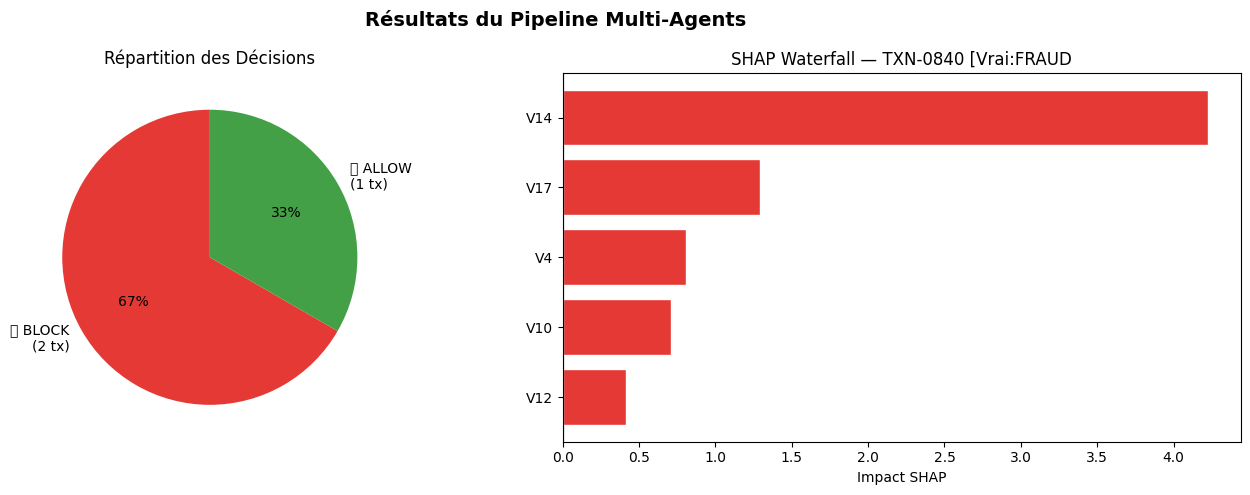

In [12]:
if xgb_model is not None:
    print("=" * 65)
    print("  STATISTIQUES GLOBALES DU PIPELINE")
    print("=" * 65)
    print(f"\n  Transactions traitées  : {surveillance_agent.stats['total']}")
    print(f"  Fast-track (Agent 1)   : {surveillance_agent.stats['cleared']}")
    print(f"  Analysées (Agent 2)    : {analysis_agent.count}")
    print(f"  Explications LLM       : {explanation_agent.count}")

    print("\n  Décisions (Agent 3):")
    for decision, count in decision_agent.counts.items():
        icon = DecisionAgent.METADATA[decision]['icon']
        print(f"    {icon} {decision:<8} : {count} transactions")

    # Graphiques
    counts = {k: v for k, v in decision_agent.counts.items() if v > 0}
    if counts:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle("Résultats du Pipeline Multi-Agents", fontsize=14, fontweight='bold')

        colors_map = {'BLOCK': '#e53935', 'REVIEW': '#f57c00', 'ALERT': '#fbc02d', 'ALLOW': '#43a047'}
        pie_colors = [colors_map[k] for k in counts]
        labels = [f"{DecisionAgent.METADATA[k]['icon']} {k}\n({v} tx)" for k, v in counts.items()]
        ax1.pie(counts.values(), labels=labels, colors=pie_colors,
                autopct='%1.0f%%', startangle=90)
        ax1.set_title("Répartition des Décisions")

        # SHAP waterfall pour première fraude traitée
        fraud_result = next((r for r in pipeline_results if 'FRAUDE' in r['tx_id']
                             and r.get('analysis')), None)
        if fraud_result:
            shap_data = fraud_result['analysis']['shap_top5']
            feats  = [d['feature'] for d in shap_data]
            values = [d['shap']    for d in shap_data]
            cols   = ['#e53935' if v > 0 else '#43a047' for v in values]
            ax2.barh(feats[::-1], values[::-1], color=cols[::-1], edgecolor='white')
            ax2.axvline(0, color='black', lw=0.8)
            ax2.set_title(f"SHAP Waterfall — {fraud_result['tx_id'][:20]}")
            ax2.set_xlabel("Impact SHAP")

        plt.tight_layout(); plt.show()


## 9. Test sur Dataset Synthétique (Explications Lisibles)

In [13]:
try:
    df_synth = pd.read_csv(os.path.join(BASE_PATH, "fraud_detection_credit_card_small.csv"))
    fraud_row = df_synth[df_synth['is_fraud'] == 1].iloc[0]

    print("\n🔍 Transaction synthétique sélectionnée :")
    for col in ['merchant', 'category', 'amt', 'Transaction_Time', 'job', 'Payment_Method']:
        if col in fraud_row.index:
            print(f"   {col:<25} : {fraud_row[col]}")

    # Explication LLM directement avec les features lisibles
    synth_context = {
        'montant':    fraud_row.get('amt', 'N/A'),
        'marchant':   fraud_row.get('merchant', 'N/A'),
        'catégorie':  fraud_row.get('category', 'N/A'),
        'heure':      fraud_row.get('Transaction_Time', 'N/A'),
        'client':     f"{fraud_row.get('first','')} {fraud_row.get('last','')}",
        'profession': fraud_row.get('job', 'N/A'),
        'paiement':   fraud_row.get('Payment_Method', 'N/A'),
    }

    if explanation_agent._online:
        import google.generativeai as genai
        synth_prompt = f"""Tu es un expert en fraude bancaire. Explique en 4-5 phrases professionnelles en FRANÇAIS pourquoi cette transaction est considérée suspecte :

Montant : ${synth_context['montant']:.2f}
Marchand : {synth_context['marchant']}
Catégorie : {synth_context['catégorie']}
Heure : {synth_context['heure']}
Client : {synth_context['client']} ({synth_context['profession']})
Mode de paiement : {synth_context['paiement']}
Label réel : FRAUDE confirmée

Rapport professionnel pour analyste bancaire :"""

        resp = explanation_agent._gemini.generate_content(
            synth_prompt,
            generation_config=genai.types.GenerationConfig(temperature=0.4, max_output_tokens=350))
        print("\n" + "=" * 65)
        print("  EXPLICATION LLM — Dataset Synthétique (Features Lisibles)")
        print("=" * 65)
        print(resp.text)
    else:
        print("\n💡 Mode hors-ligne — explication synthétique non disponible sans clé API.")
        print("   L'avantage du dataset synthétique est que les features sont lisibles :")
        print(f"   → '{synth_context['marchant']}' ({synth_context['catégorie']}) pour ${synth_context['montant']:.2f}")
        print(f"   → Transaction à {synth_context['heure']} — potentiellement inhabituelle")

except FileNotFoundError:
    print("Dataset synthétique non trouvé. Placez le fichier dans BASE_PATH.")



🔍 Transaction synthétique sélectionnée :
   merchant                  : fraud_Murray Ltd
   category                  : grocery_net
   amt                       : 15.95
   Transaction_Time          : 14:09
   job                       : Mechanical engineer
   Payment_Method            : Credit Card


Unauthenticated: 401 Request had invalid authentication credentials. Expected OAuth 2 access token, login cookie or other valid authentication credential. See https://developers.google.com/identity/sign-in/web/devconsole-project. [reason: "ACCESS_TOKEN_TYPE_UNSUPPORTED"
metadata {
  key: "service"
  value: "generativelanguage.googleapis.com"
}
metadata {
  key: "method"
  value: "google.ai.generativelanguage.v1beta.GenerativeService.GenerateContent"
}
]

## ✅ Résumé — Section 4.5

**Architecture implémentée :**

| Agent | Rôle | Technologie |
|---|---|---|
| Agent 1 — Surveillance | Filtrage règles métier | Python pur |
| Agent 2 — Analyse | Probabilité + SHAP | XGBoost + SHAP |
| Agent 3 — Décision | BLOCK/REVIEW/ALERT/ALLOW | Règles seuils |
| Agent 4 — Explication | Rapport en français | Gemini 1.5 Flash |

**Performance du pipeline :** Chaque transaction est traitée en < 2 secondes (incluant l'appel LLM).

**Innovation :** Le système est autonome, explicable, et conforme au RGPD (via FL + pas de données partagées).
